
▶ Showing asestra_eco_1: AA_sequences.nk


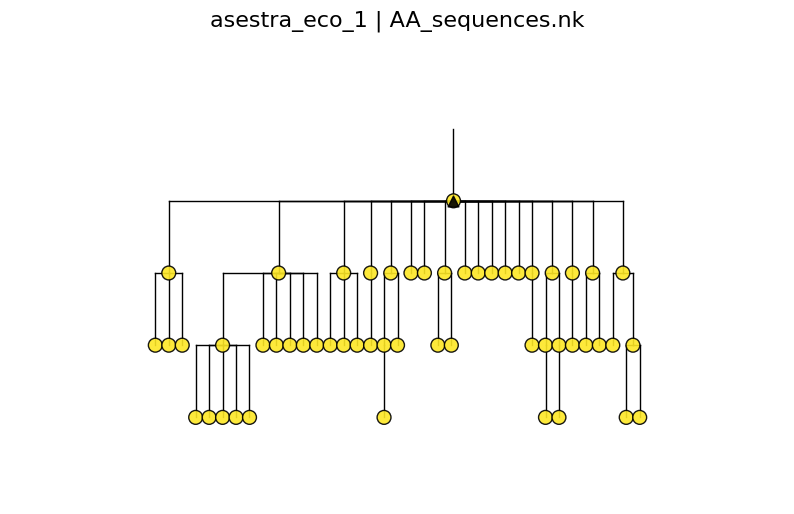


▶ Showing asestra_eco_2: AA_sequences.nk


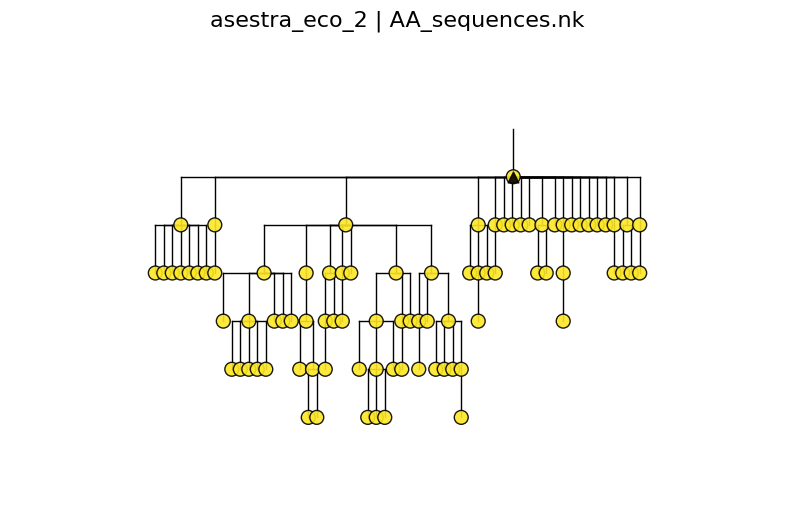


▶ Showing asestra_eco_3: AA_sequences.nk


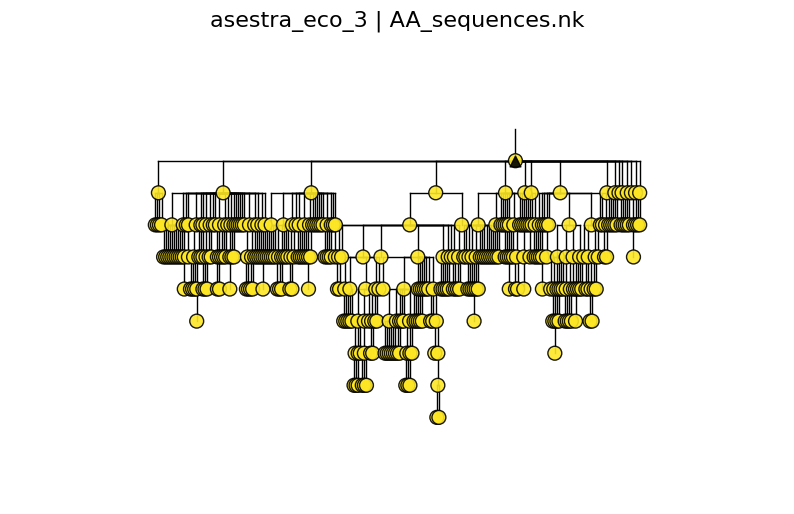


▶ Showing asestra_eco_4: AA_sequences.nk


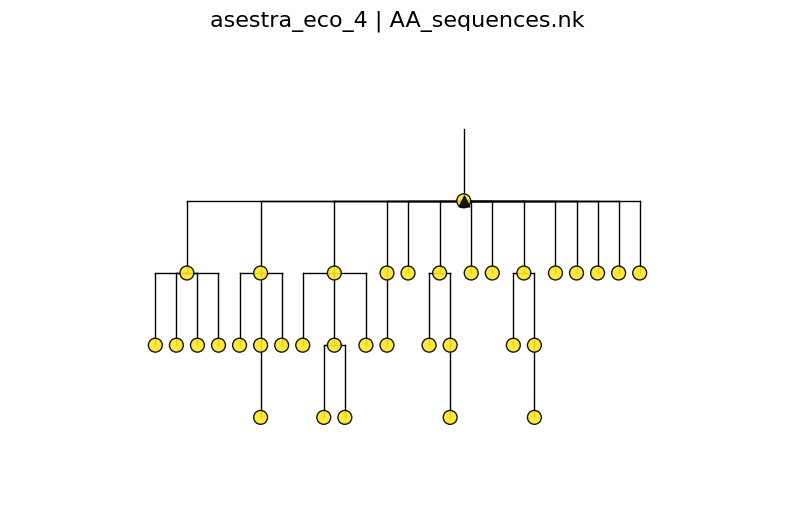


################################################################################
DONE VISUALIZING DATASETS
✅ shown: 4
⏭️ skipped (missing outputs): 0
################################################################################


In [1]:
import os
import re
import sys
from ete3 import Tree
from matplotlib import cm
import mplcursors
import numpy as np
import matplotlib.pyplot as plt


def plot_newick_bcellTree(newick, node_weights, title_name="Tree"):
    def rectangular_layout(tree):
        positions = {}
        x_offset = 0
        y_offset = 0
        level_spacing = 50
        sibling_spacing = 100

        def assign_positions(node, y):
            nonlocal x_offset
            if node.is_leaf():
                positions[node.name] = (x_offset, y)
                x_offset += sibling_spacing
            else:
                child_xs = []
                for child in node.children:
                    assign_positions(child, y - level_spacing)
                    child_xs.append(positions[child.name][0])
                positions[node.name] = (sum(child_xs) / len(child_xs), y)

        assign_positions(tree, y_offset)
        return positions

    node_info = {k: f"Node_name: {k}\n\nAbundancy: {int(v)}" for k, v in node_weights.items()}

    t = Tree(newick, format=1)
    tree_nodes = [node.name for node in t.traverse() if node.name]
    tree_nodes_set = set(tree_nodes)

    for k in tree_nodes_set:
        if k not in node_weights:
            node_weights[k] = 1
        if k not in node_info:
            node_info[k] = f"Node_name: {k}\n\nAbundancy: 1"

    max_weight = max(node_weights.values()) if node_weights else 1
    weights = np.array([node_weights[n] for n in tree_nodes], dtype=float) if tree_nodes else np.array([1.0])

    if max_weight <= 1:
        node_sizes = {n: 100 for n in tree_nodes}
        colors = cm.viridis(weights)
    else:
        node_sizes = {n: (node_weights[n] / max_weight) * 1000 for n in tree_nodes}
        normalized = (weights - weights.min()) / (weights.max() - weights.min() + 1e-12)
        colors = cm.viridis(normalized)

    node_colors = {n: colors[i] for i, n in enumerate(tree_nodes)}

    pos = rectangular_layout(t)

    fig = plt.figure(figsize=(10, 6))
    try:
        fig.canvas.manager.set_window_title(title_name)
    except Exception:
        pass

    # ✅ Visible title inside the figure (good for screenshots)
    plt.title(title_name, fontsize=16, pad=12)

    if pos:
        x_coords = [x for x, y in pos.values()]
        y_coords = [y for x, y in pos.values()]
        x_range = (max(x_coords) - min(x_coords)) or 1
        y_range = (max(y_coords) - min(y_coords)) or 1
        x_margin = x_range * 0.3
        y_margin = y_range * 0.3
        plt.gca().set_xlim(min(x_coords) - x_margin, max(x_coords) + x_margin)
        plt.gca().set_ylim(min(y_coords) - y_margin, max(y_coords) + y_margin)

    xy = [pos[n] for n in tree_nodes if n in pos]
    sizes = [node_sizes.get(n, 50) for n in tree_nodes if n in pos]
    cols = [node_colors.get(n, (0, 0, 0, 1)) for n in tree_nodes if n in pos]

    scatter = plt.scatter(
        [p[0] for p in xy],
        [p[1] for p in xy],
        s=sizes,
        alpha=0.9,
        c=cols,
        edgecolor="black",
        zorder=2,
    )

    if "naive" in tree_nodes_set and "naive" in pos:
        plt.scatter(
            pos["naive"][0],
            pos["naive"][1],
            s=60,
            alpha=0.9,
            color="black",
            edgecolor="black",
            zorder=3,
            marker="^",
        )

    for node in t.traverse("postorder"):
        if node.is_root():
            continue
        parent = node.up
        if parent.name in pos and node.name in pos:
            x_start, y_start = pos[parent.name]
            x_end, y_end = pos[node.name]
            plt.plot([x_start, x_end], [y_start, y_start], color="black", lw=1, zorder=1)
            plt.plot([x_end, x_end], [y_start, y_end], color="black", lw=1, zorder=1)

    plt.axis("off")

    cursor = mplcursors.cursor(scatter, hover=True)
    visible_nodes = [n for n in tree_nodes if n in pos]

    @cursor.connect("add")
    def on_add(sel):
        node_name = visible_nodes[sel.index]
        sel.annotation.set_text(node_info.get(node_name, "No information available"))
        sel.annotation.set_multialignment("left")
        sel.annotation.set_bbox(
            dict(
                boxstyle="round,pad=0.7",
                edgecolor="black",
                facecolor="yellow",
                linewidth=1,
                alpha=0.7,
            )
        )
        sel.annotation.arrowprops = None

    plt.show()


def extract_names_from_newick(newick_str):
    cleaned = re.sub(r":\d+(\.\d+)?", "", newick_str)
    names = re.findall(r"\b[a-zA-Z0-9_@]+\b", cleaned)
    names = [n for n in names if n not in ("", "(", ")", ",", ";")]
    return list(dict.fromkeys(names))


def read_newick_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read().strip()


def main():
    # ✅ Your new results directory
    outputs_dir = r"C:\Users\LEGION\Downloads\AA_Code\ground_truth"

    if not os.path.isdir(outputs_dir):
        print(f"ERROR: outputs directory not found: {outputs_dir}")
        sys.exit(1)

    patterns = [
        os.path.join("{ds}", "AA_sequences.nk"),
    ]

    ok, skipped = 0, 0

    for i in range(1, 5):
        ds = f"asestra_eco_{i}"

        # try standard patterns
        newick_path = None
        for pat in patterns:
            cand = os.path.join(outputs_dir, pat.format(ds=ds))
            if os.path.exists(cand):
                newick_path = cand
                break

        # fallback: any .nk inside the dataset folder
        if newick_path is None:
            dataset_folder = os.path.join(outputs_dir, ds)
            if os.path.isdir(dataset_folder):
                candidates = [
                    os.path.join(dataset_folder, f)
                    for f in os.listdir(dataset_folder)
                    if f.lower().endswith(".nk")
                ]
                if candidates:
                    candidates.sort()
                    newick_path = candidates[0]

        if newick_path is None:
            print(f"⏭️  SKIP {ds}: no Newick output found")
            skipped += 1
            continue

        print(f"\n▶ Showing {ds}: {os.path.basename(newick_path)}")

        newick_str = read_newick_file(newick_path)
        names = extract_names_from_newick(newick_str)
        node_weights = {name: 1 for name in names}

        # Title that appears on the plot
        title = f"{ds} | {os.path.basename(newick_path)}"
        plot_newick_bcellTree(newick_str, node_weights, title_name=title)

        ok += 1

    print("\n" + "#" * 80)
    print("DONE VISUALIZING DATASETS")
    print(f"✅ shown: {ok}")
    print(f"⏭️ skipped (missing outputs): {skipped}")
    print("#" * 80)


if __name__ == "__main__":
    main()